In [1]:
import os
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [2]:
from utils.plot_style import set_plot_style 

In [3]:
wavelength = 780e-9  # 780 nm in meters

## QPM Temperature

In [4]:
# path_folder_data = r"./data/data_temp_SHG/temp_scan 04 29"
# path_folder_data = r"./data/data_temp_SHG/temp_scan 05 05"
path_folder_data = r"./data/data_temp_SHG/temp_scan 05 13"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'temperature_scan', 'temperature_scan_summary']


In [34]:
# fine data scan :
name_exp = 'temperature_scan'
# name = "2026_04_29__15_59_36__temperature_scan.h5"
# name = "2026_05_05__08_48_24__temperature_scan.h5"
name = "2026_05_13__11_59_17__temperature_scan.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

print(aqm.data)

INFO:2026_05_13__11_59_17__temperature_scan


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "5.221e+02 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "list_SHG_errors" (r): "shape: (41,) (type: ndarray)",
    "list_SHG_powers" (r): "shape: (41,) (type: ndarray)",
    "list_Terrors" (r): "shape: (41,) (type: ndarray)",
    "list_Tmeas" (r): "shape: (41,) (type: ndarray)",
    "pump_power_mW" (r): "300 (type : int64)",
    "useful" (r): "variable of type bool"
}


In [35]:
list_T = np.array(aqm.data['list_Tmeas'])
list_P = np.array(aqm.data['list_SHG_powers'])
list_Perr = np.array(aqm.data['list_SHG_errors'])
list_Terr = np.array(aqm.data['list_Terrors'])

In [29]:
threshold = 0.005  # adjust based on your noise floor

mask = list_P > threshold

list_P = list_P[mask]
list_T = list_T[mask]
list_Perr = list_Perr[mask]
list_Terr = list_Terr[mask]

In [36]:
# Quasi-phase-matching fit function
def qpm_fit(T, I0, T0, dT, B):
    """
    A_fit = I0 * sinc^2( (T - T0) / dT ) + B
    """
    x = (T - T0) / dT
    return I0 * ((np.sinc(x))**2) + B

In [37]:
# protect against zero/invalid uncertainties
sigma = np.asarray(list_Perr, dtype=float)
sigma[~np.isfinite(sigma) | (sigma <= 0)] = np.nanmedian(sigma[sigma > 0])

p0 = [
    np.max(list_P) - np.min(list_P),
    list_T[np.argmax(list_P)],
    (np.max(list_T) - np.min(list_T)) / 10,
    np.min(list_P)
]

bounds = (
    [0, np.min(list_T), 1e-6, -np.inf],   # lower: I0, T0, dT, B
    [np.inf, np.max(list_T), np.inf, np.inf]
)

popt, pcov = curve_fit(
    qpm_fit,
    list_T,
    list_P,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

I0, T0, dT, B = popt
perr = np.sqrt(np.diag(pcov))

print(f"Estimated temperature for maximum SHG power: {T0:.3f} ± {perr[1]:.3f} °C")
print(f"I0 = {I0:.4g} ± {perr[0]:.4g}")
print(f"dT = {dT:.4g} ± {perr[2]:.4g}")
print(f"B  = {B:.4g} ± {perr[3]:.4g}")

Tfit = np.linspace(np.min(list_T), np.max(list_T), 1000)
Pfit = qpm_fit(Tfit, *popt)


Estimated temperature for maximum SHG power: 42.335 ± 0.000 °C
I0 = 2.647 ± 0.005986
dT = 0.5857 ± 0.001307
B  = 0.2564 ± 0.002668


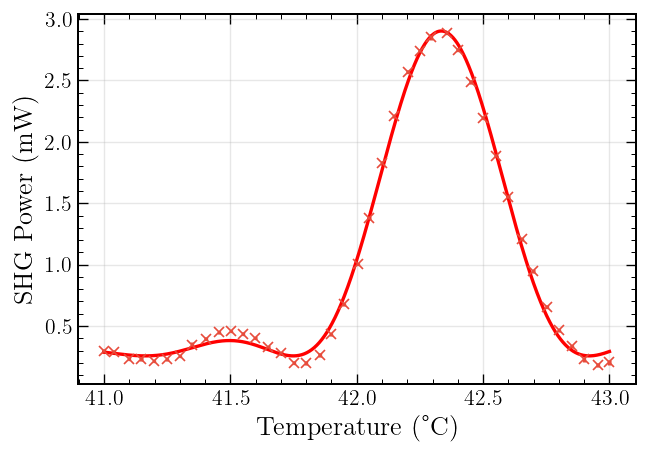

In [39]:
set_plot_style()

plt.errorbar(list_T, list_P , xerr=list_Terr, yerr=list_Perr, fmt='x', label='data')
plt.plot(Tfit, qpm_fit(Tfit, *popt), 'r-', label='fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('SHG Power (mW)')
# plt.title('SHG Power vs Temperature')
plt.grid()
plt.show()


## Waist scan

In [12]:
# Manually define the waist corresponding to each focal length
# Forgot to add it before in the acquisition notebook, so I add it here for the plot
# Won't be necessary for the future, it is added in the acquisition notebook
waists = {
    500.0: 70.1,  # mm & µm
    400.0: 53.5,  # mm & µm
    200.0: 24.5   # mm & µm
}

In [13]:
path_folder_data = r"./data/data_temp_SHG/waist_scan 05 05"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'waist_scan']


In [14]:
# List all files in the folder
name_exp = 'waist_scan'
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['2026_05_05__15_08_16__waist_scan.h5', '2026_05_05__15_10_23__waist_scan.h5', '2026_05_05__15_15_47__waist_scan.h5']


In [15]:

w_list = []
eta_list = []
eta_err_list = []

aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))

for name in folder_data_files:
    full_path = os.path.join(path_folder_data, name_exp, name)
    aqm.analysis_cell(filename=full_path)

    Pin = float(aqm.data["Pin"])        # mW
    Pshg = float(aqm.data["mean_mW"])   # mW
    Perr = float(aqm.data["error_mW"])  # mW

    eta = Pshg / Pin # conversion efficiency
    eta_err = Perr / Pin

    f = float(aqm.data["focal_length_mm"])
    waist = waists.get(f, None)

    w_list.append(waist)
    eta_list.append(eta)
    eta_err_list.append(eta_err)

    # print(aqm.data)

INFO:2026_05_05__15_08_16__waist_scan


INFO:2026_05_05__15_10_23__waist_scan


INFO:2026_05_05__15_15_47__waist_scan


In [16]:
# Convert to arrays
w = np.array(w_list)
eta = np.array(eta_list)
eta_err = np.array(eta_err_list)

print("Waists (µm):", w)
print("Conversion efficiencies:", eta)

Waists (µm): [53.5 24.5 70.1]
Conversion efficiencies: [0.0006781  0.00140509 0.00060392]


In [17]:
# Fit the data to the model eta(w0) = A * w0^2 / (w0^4 + wc^4)
def eta_model(w0, A, wc):
    """
    For larger waists, the conversion efficiency decreases as 1/w0^2, while for smaller waists, it decreases as w0^2. The maximum efficiency occurs at w0 = wc, where eta(wc) = A/2.
    :param w0: beam waist (µm)
    :param A: maximum conversion efficiency (at w0 = wc)
    :param wc: optimal beam waist for maximum conversion efficiency (µm)

    :return: conversion efficiency eta
    """
    return A * w0**2 / (w0**4 + wc**4)

# Initial guess for fitting parameters
p0 = [np.max(eta), np.mean(w)]
popt, pcov = curve_fit(eta_model, w, eta, p0=p0, sigma=eta_err, absolute_sigma=True)
w_fit = np.linspace(10, 80, 200)
eta_fit_values = eta_model(w_fit, *popt)

In [18]:
L = 20e-3  # 20 mm in meters

# Boyd-Kleinman focusing function for perfect phase matching
def bk_h(xi):
    """
    Minimal Boyd-Kleinman focusing function for perfect phase matching.
    :param xi: xi = L / (2 z_R)
    """

    def integrand(t):
        return 1 / (1 + 1j*t)

    val, _ = quad(lambda t: np.real(integrand(t)), -xi, xi)
    vali, _ = quad(lambda t: np.imag(integrand(t)), -xi, xi)

    I = val + 1j * vali

    return np.abs(I)**2 / (4 * xi)


def eta_bk(w0_um, A, s):
    """
    Boyd-Kleinman model for SHG efficiency.
    :param w0_um: measured waist in um
    :param A: global efficiency scale
    :param s: waist calibration factor

    :return: conversion efficiency eta 
    """

    w0 = s * w0_um * 1e-6
    zR = np.pi * w0**2 / wavelength
    xi = L / (2 * zR)

    h = np.array([bk_h(x) for x in xi])

    return A * h

p0 = [np.max(eta), 1.0]

popt, pcov = curve_fit(
    eta_bk,
    w,
    eta,
    p0=p0,
    sigma=eta_err,
    absolute_sigma=True,
    bounds=([0, 0.3], [np.inf, 3.0]),
    maxfev=10000
)

A_fit, s_fit = popt

print(f"A = {A_fit:.4e}")
print(f"waist calibration factor s = {s_fit:.3f}")

w_fit = np.linspace(10, 90, 200)
eta_fit_values_bk = eta_bk(w_fit, *popt)

A = 2.2246e-03
waist calibration factor s = 1.517


Optimal waist from simple model: 30.9 µm
Optimal waist from Boyd-Kleinman model: 27.7 µm


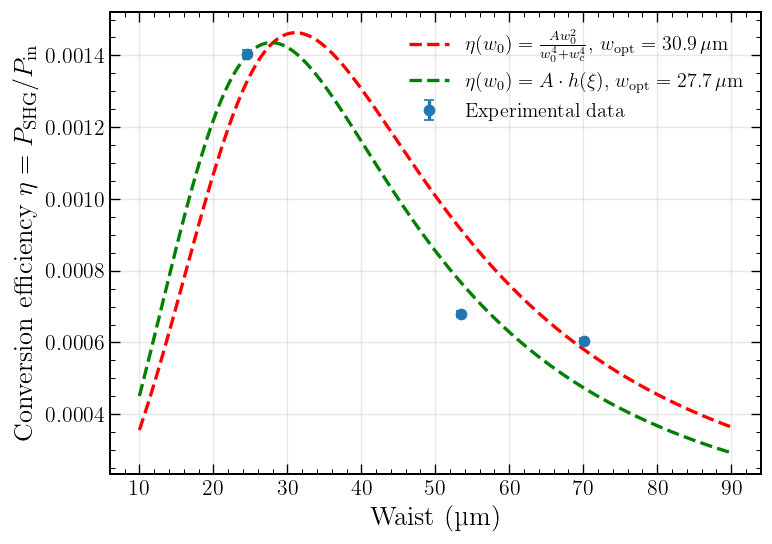

In [20]:
# Plot the coefficient eta vs waist
plt.figure(figsize=(7,5))

plt.errorbar(w, eta, yerr=eta_err, fmt='o', capsize=3, label='Experimental data')

# Curve fits
w0_optimal = w_fit[np.argmax(eta_fit_values)]
w0_optimal_bk = w_fit[np.argmax(eta_fit_values_bk)]
print(f"Optimal waist from simple model: {w0_optimal:.1f} µm")
print(f"Optimal waist from Boyd-Kleinman model: {w0_optimal_bk:.1f} µm")
# plt.plot(w_fit[w0_optimal], eta_fit_values[w0_optimal], 'rx', label=f'$w_{{opt}}=${w_fit[w0_optimal]:.1f} µm')
# plt.plot(w_fit[w0_optimal_bk], eta_fit_values_bk[w0_optimal_bk], 'gx', label=f'$w_{{opt}}=${w_fit[w0_optimal_bk]:.1f} µm')
plt.plot(
    w_fit,
    eta_fit_values,
    'r--',
    label=rf'$\eta(w_0)=\frac{{A w_0^2}}{{w_0^4+w_c^4}}$, '
          rf'$w_{{\mathrm{{opt}}}}={w0_optimal:.1f}\,\mu\mathrm{{m}}$'
)

plt.plot(
    w_fit,
    eta_fit_values_bk,
    'g--',
    label=rf'$\eta(w_0) = A \cdot h(\xi)$, '
          rf'$w_{{\mathrm{{opt}}}}={w0_optimal_bk:.1f}\,\mu\mathrm{{m}}$'
)

plt.xlabel("Waist (µm)")
plt.ylabel(r"Conversion efficiency $\eta = P_{\mathrm{SHG}} / P_{\mathrm{in}}$")
# plt.title("SHG efficiency vs waist")
plt.legend(loc='upper right')

plt.grid(alpha=0.3)
# plt.tight_layout()
plt.show()

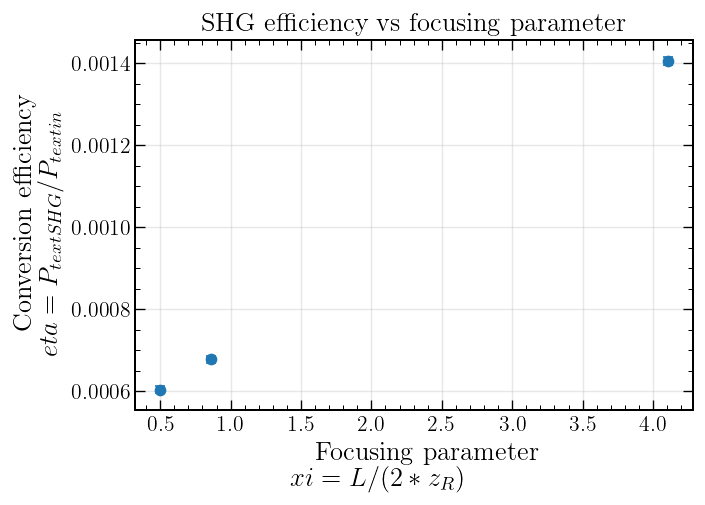

In [23]:
# Plot efficiency eta vs focusing parameter xi = L / (2 * z_R)
L = 20.0  # mm
z_R = np.pi * w**2 / (780-6)  # Rayleigh range in mm
xi = L / (2 * z_R)
plt.figure()
plt.errorbar(xi, eta, yerr=eta_err, fmt='o', capsize=3)
plt.xlabel(r"Focusing parameter $\\xi = L / (2 * z_R)$")
plt.ylabel(r"Conversion efficiency $\\eta = P_{\\text{SHG}} / P_{\\text{in}}$")
plt.title("SHG efficiency vs focusing parameter")
plt.grid()
plt.show()